# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages.

In [1]:
!python -m pip install kaggle==1.6.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.12-py3-none-any.whl size=102970 sha256=186ec30f99239e15d527f5b9ad28d763e7759f5eb6a21c928fe0c721fbcb3317
  Stored in directory: /root/.cache/pip/wheels/f3/eb/e9/819c2d9eac90204eec8579430759f75a1d6dbe4cd0b93f53bc
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.2
    Uninstalling kaggle-1.7.4.2:
      Successfully uninstalled kaggle-1.7.4.2


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.3 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.24.3 which is inc

**Note:** Restart the kernel to use updated package(s).

## Import libraries

In [1]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import ticker
from matplotlib.ticker import StrMethodFormatter

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
The goal of this project is to examine whether car sales are affected by fluctuations in fuel prices. Specifically, I want to analyze if car sales increase when fuel prices decrease and vice versa, or if car sales remain unaffected. To explore this, I will be wrangling a dataset from the DVM car listings (from Kaggle)

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code).

Load the dataset programmtically into this notebook.

#### **Dataset 1: Car Sales Data**

The first dataset is the DVM Car Sales dataset, downloaded from Kaggle using the Kaggle API. It is available at the following link:

https://www.kaggle.com/datasets/mexwell/dvm-car

rom this dataset, I will only be using the Sales_table.csv file. This file contains annual car sales data for various car models. Key columns include:


*   Maker: Manufacturer of the car

*   Genmodel: Car model name

*   Genmodel_ID: Unique identifier for the car model
*   Columns 2020–2001: Annual sales figures for each model from 2001 to 2020

This dataset provides the foundation for analyzing trends in car sales over time.

**Download the dataset**

In [2]:
!kaggle datasets download -d mexwell/dvm-car

Dataset URL: https://www.kaggle.com/datasets/mexwell/dvm-car
License(s): other
dvm-car.zip: Skipping, found more recently modified local copy (use --force to force download)


**Unzipping the File**

In [3]:
with zipfile.ZipFile('./dvm-car.zip') as z:
    with z.open('Sales_table.csv') as f:
        carSalesDf = pd.read_csv(f)

carSalesDf.columns

Index(['Maker', 'Genmodel', 'Genmodel_ID', '2020', '2019', '2018', '2017',
       '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008',
       '2007', '2006', '2005', '2004', '2003', '2002', '2001'],
      dtype='object')

#### Dataset 2: UK Fuel Price Statistics
The second dataset, fuel_price.csv, was manually downloaded from Kaggle and can be accessed here:

🔗 https://www.kaggle.com/datasets/benten867/uk-fuel-price-weekly-statistics20032020

This dataset contains weekly fuel price statistics in the UK from 2003 to 2020. It includes information on both petrol and diesel prices, along with corresponding tax rates. Key columns include:

* "Unnamed: 0": Index column

* Date: Date when the data was recorded

* Pump price in pence/litre (ULSP): Price of Ultra Low Sulphur Petrol

* Pump price in pence/litre (ULSD): Price of Ultra Low Sulphur Diesel

* Duty rate in pence/litre (ULSP): Petrol duty (tax) per litre

* Duty rate in pence/litre (ULSD): Diesel duty (tax) per litre

* VAT percentage rate (ULSP): Value Added Tax rate applied to petrol

* VAT percentage rate (ULSD): Value Added Tax rate applied to diesel

Abbreviations:

* ULSP = Ultra Low Sulphur Petrol
* ULSD = Ultra Low Sulphur Diesel

This dataset will be used to explore how fluctuations in fuel prices and tax rates correlate with car sales over time.




**Open the File**

In [5]:
fuelPricesDf = pd.read_csv('./fuel price.csv')
fuelPricesDf.columns

Index(['Unnamed: 0', 'Date', 'Pump price in pence/litre (ULSP)',
       'Pump price in pence/litre (ULSD)', 'Duty rate in pence/litre (ULSP)',
       'Duty rate in pence/litre (ULSD)', 'VAT percentage rate (ULSP)',
       'VAT percentage rate (ULSD)'],
      dtype='object')

In [7]:
fuelPricesDf.head()

,Unnamed: 0,Date,Pump price in pence/litre (ULSP),Pump price in pence/litre (ULSD),Duty rate in pence/litre (ULSP),Duty rate in pence/litre (ULSD),VAT percentage rate (ULSP),VAT percentage rate (ULSD)
0,2,09/06/2003,74.59,76.77,45.82,45.82,17.5,17.5
1,3,16/06/2003,74.47,76.69,45.82,45.82,17.5,17.5
2,4,23/06/2003,74.42,76.62,45.82,45.82,17.5,17.5
3,5,30/06/2003,74.35,76.51,45.82,45.82,17.5,17.5
4,6,07/07/2003,74.28,76.46,45.82,45.82,17.5,17.5


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### **Assessing carSalesDf**

In [8]:
carSalesDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Maker        773 non-null    object
 1   Genmodel     773 non-null    object
 2   Genmodel_ID  773 non-null    object
 3   2020         773 non-null    int64 
 4   2019         773 non-null    int64 
 5   2018         773 non-null    int64 
 6   2017         773 non-null    int64 
 7   2016         773 non-null    int64 
 8   2015         773 non-null    int64 
 9   2014         773 non-null    int64 
 10  2013         773 non-null    int64 
 11  2012         773 non-null    int64 
 12  2011         773 non-null    int64 
 13  2010         773 non-null    int64 
 14  2009         773 non-null    int64 
 15  2008         773 non-null    int64 
 16  2007         773 non-null    int64 
 17  2006         773 non-null    int64 
 18  2005         773 non-null    int64 
 19  2004         773 non-null    

In [9]:
carSalesDf.duplicated().sum()

np.int64(0)

no NULL Data and no duplicates

In [10]:
carSalesDf.head()

,Maker,Genmodel,Genmodel_ID,2020,2019,2018,2017,2016,2015,2014,...,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
0,ABARTH,ABARTH 124,2_1,0,19,27,60,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ABARTH,ABARTH 500,2_2,0,0,1,2,66,717,762,...,915,766,0,0,0,0,0,0,0,0
2,ABARTH,ABARTH 595,2_4,2144,2866,3907,3295,3132,1612,516,...,0,0,0,0,0,0,0,0,0,0
3,ABARTH,ABARTH 695,2_6,45,65,270,114,29,10,14,...,0,0,0,0,0,0,0,0,0,0
4,ABARTH,ABARTH PUNTO,2_9,0,0,0,0,0,0,56,...,97,172,74,0,0,0,0,0,0,0


In [11]:
carSalesDf.describe()

,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,1979.454075,2818.445019,2862.076326,2963.058215,3203.897801,3132.236740,2915.015524,2628.974127,2314.923674,2131.992238,2165.604140,2041.534282,1941.636481,1976.517464,1626.055627,1325.930142,1058.534282,805.106080,564.614489,349.142303
std,5403.526805,7466.655137,7731.051191,8199.212870,9234.009443,9571.845809,9085.533712,8520.582424,7742.340436,7122.691281,7249.633197,7136.761258,6755.753065,6958.049764,5690.905348,4616.839607,3683.193277,2989.763318,2200.688401,1342.884560
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,794.000000,1440.000000,1427.000000,1437.000000,1392.000000,1287.000000,946.000000,846.000000,684.000000,612.000000,674.000000,602.000000,560.000000,550.000000,480.000000,418.000000,224.000000,106.000000,62.000000,36.000000
max,46739.000000,74500.000000,89564.000000,87409.000000,113568.000000,125619.000000,122815.000000,113390.000000,100228.000000,87266.000000,91353.000000,100975.000000,73429.000000,77257.000000,68079.000000,58824.000000,43404.000000,32345.000000,26767.000000,15737.000000


### **Assessing fuelPricseDf**

In [12]:
fuelPricesDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        909 non-null    int64  
 1   Date                              909 non-null    object 
 2   Pump price in pence/litre (ULSP)  909 non-null    float64
 3   Pump price in pence/litre (ULSD)  909 non-null    float64
 4   Duty rate in pence/litre (ULSP)   909 non-null    float64
 5   Duty rate in pence/litre (ULSD)   909 non-null    float64
 6   VAT percentage rate (ULSP)        909 non-null    float64
 7   VAT percentage rate (ULSD)        909 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 56.9+ KB


In [13]:
fuelPricesDf.duplicated().sum()

np.int64(0)

no NULL Data and no duplicates

In [14]:
fuelPricesDf.head()

,Unnamed: 0,Date,Pump price in pence/litre (ULSP),Pump price in pence/litre (ULSD),Duty rate in pence/litre (ULSP),Duty rate in pence/litre (ULSD),VAT percentage rate (ULSP),VAT percentage rate (ULSD)
0,2,09/06/2003,74.59,76.77,45.82,45.82,17.5,17.5
1,3,16/06/2003,74.47,76.69,45.82,45.82,17.5,17.5
2,4,23/06/2003,74.42,76.62,45.82,45.82,17.5,17.5
3,5,30/06/2003,74.35,76.51,45.82,45.82,17.5,17.5
4,6,07/07/2003,74.28,76.46,45.82,45.82,17.5,17.5


In [15]:
fuelPricesDf.describe()

,Unnamed: 0,Pump price in pence/litre (ULSP),Pump price in pence/litre (ULSD),Duty rate in pence/litre (ULSP),Duty rate in pence/litre (ULSD),VAT percentage rate (ULSP),VAT percentage rate (ULSD)
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,456.000000,111.090583,115.631617,54.523080,54.523080,18.754125,18.754125
std,262.549995,18.308105,19.414181,4.664805,4.664805,1.532611,1.532611
min,2.000000,74.210000,76.410000,45.820000,45.820000,15.000000,15.000000
25%,229.000000,95.710000,99.180000,50.350000,50.350000,17.500000,17.500000
50%,456.000000,113.720000,118.110000,57.950000,57.950000,20.000000,20.000000
75%,683.000000,127.540000,132.600000,57.950000,57.950000,20.000000,20.000000
max,910.000000,142.170000,148.040000,58.950000,58.950000,20.000000,20.000000


### Quality Issue 1: The pump price columns Pump price in pence/litre (ULSP) and Pump price in pence/litre (ULSD) are stored as floating-point numbers float64. However, since the prices are expressed in pence, decimal precision is unnecessary.

In [16]:
fuelPricesDf['Pump price in pence/litre (ULSP)'].dtype

dtype('float64')

In [17]:
fuelPricesDf['Pump price in pence/litre (ULSD)'].dtype

dtype('float64')

To optimize calculations and reduce memory usage, pump prices will be converted from float to integer values.

### Quality Issue 2: The Date column in the fuel price dataset is currently stored as a string (object type). This prevents proper time-based analysis or transformations.

In [18]:
fuelPricesDf['Date'].dtype

dtype('O')

In [19]:
type(fuelPricesDf['Date'][0])

str

The Date column is currently stored as a string, but it should be converted to a datetime format. For the purpose of this analysis, only the year component will be extracted to align fuel price trends with annual car sales data.

### Quality Issue 3: The data contains sales columns from 2001 to 2020 in separate columns, which makes it harder to analyze or visualize trends over time.


In [20]:
carSalesDf.describe()

,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,1979.454075,2818.445019,2862.076326,2963.058215,3203.897801,3132.236740,2915.015524,2628.974127,2314.923674,2131.992238,2165.604140,2041.534282,1941.636481,1976.517464,1626.055627,1325.930142,1058.534282,805.106080,564.614489,349.142303
std,5403.526805,7466.655137,7731.051191,8199.212870,9234.009443,9571.845809,9085.533712,8520.582424,7742.340436,7122.691281,7249.633197,7136.761258,6755.753065,6958.049764,5690.905348,4616.839607,3683.193277,2989.763318,2200.688401,1342.884560
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,794.000000,1440.000000,1427.000000,1437.000000,1392.000000,1287.000000,946.000000,846.000000,684.000000,612.000000,674.000000,602.000000,560.000000,550.000000,480.000000,418.000000,224.000000,106.000000,62.000000,36.000000
max,46739.000000,74500.000000,89564.000000,87409.000000,113568.000000,125619.000000,122815.000000,113390.000000,100228.000000,87266.000000,91353.000000,100975.000000,73429.000000,77257.000000,68079.000000,58824.000000,43404.000000,32345.000000,26767.000000,15737.000000


Justification: Keeping year columns in wide format violates best practices for time-series analysis. Converting them to long format enables easier merging, analysis, and plotting over time.


### Tidiness Issue 1:

In [21]:
fuelPricesDf.head(3)

,Unnamed: 0,Date,Pump price in pence/litre (ULSP),Pump price in pence/litre (ULSD),Duty rate in pence/litre (ULSP),Duty rate in pence/litre (ULSD),VAT percentage rate (ULSP),VAT percentage rate (ULSD)
0,2,09/06/2003,74.59,76.77,45.82,45.82,17.5,17.5
1,3,16/06/2003,74.47,76.69,45.82,45.82,17.5,17.5
2,4,23/06/2003,74.42,76.62,45.82,45.82,17.5,17.5


Unnamed column is another index and we already have one so we dont need it

### Tidiness Issue 2:


In [22]:
fuelPricesDf.head(3)

,Unnamed: 0,Date,Pump price in pence/litre (ULSP),Pump price in pence/litre (ULSD),Duty rate in pence/litre (ULSP),Duty rate in pence/litre (ULSD),VAT percentage rate (ULSP),VAT percentage rate (ULSD)
0,2,09/06/2003,74.59,76.77,45.82,45.82,17.5,17.5
1,3,16/06/2003,74.47,76.69,45.82,45.82,17.5,17.5
2,4,23/06/2003,74.42,76.62,45.82,45.82,17.5,17.5


Justification: Simplifying long column names improves readability and makes the dataset easier to work with during analysis and visualization. This change supports tidy data principles by ensuring variable names are consistent and manageable.


### Tidiness Issue 3: The years (2001 to 2020) are stored as column headers, but they should be values in a 'Year' column instead.



In [23]:
carSalesDf.head(5)

,Maker,Genmodel,Genmodel_ID,2020,2019,2018,2017,2016,2015,2014,...,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
0,ABARTH,ABARTH 124,2_1,0,19,27,60,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ABARTH,ABARTH 500,2_2,0,0,1,2,66,717,762,...,915,766,0,0,0,0,0,0,0,0
2,ABARTH,ABARTH 595,2_4,2144,2866,3907,3295,3132,1612,516,...,0,0,0,0,0,0,0,0,0,0
3,ABARTH,ABARTH 695,2_6,45,65,270,114,29,10,14,...,0,0,0,0,0,0,0,0,0,0
4,ABARTH,ABARTH PUNTO,2_9,0,0,0,0,0,0,56,...,97,172,74,0,0,0,0,0,0,0


## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [24]:
fuelPricesDfClean = fuelPricesDf.copy()

### **Quality Issue 1:** The pump price columns ('Pump price in pence/litre (ULSP)' and 'Pump price in pence/litre (ULSD)') are stored as float values. Since these prices are in pence, they do not require decimal precision and can be represented as integers instead.

In [25]:
fuelPricesDfClean['Pump price in pence/litre (ULSP)'] = fuelPricesDfClean['Pump price in pence/litre (ULSP)'].astype(int)

In [26]:
fuelPricesDfClean['Pump price in pence/litre (ULSD)'] = fuelPricesDfClean['Pump price in pence/litre (ULSD)'].astype(int)

In [27]:
fuelPricesDfClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        909 non-null    int64  
 1   Date                              909 non-null    object 
 2   Pump price in pence/litre (ULSP)  909 non-null    int64  
 3   Pump price in pence/litre (ULSD)  909 non-null    int64  
 4   Duty rate in pence/litre (ULSP)   909 non-null    float64
 5   Duty rate in pence/litre (ULSD)   909 non-null    float64
 6   VAT percentage rate (ULSP)        909 non-null    float64
 7   VAT percentage rate (ULSD)        909 non-null    float64
dtypes: float64(4), int64(3), object(1)
memory usage: 56.9+ KB


converting them to ING make it easier to to make calculations

### **Quality Issue 2: converting the date to a year base**

In [28]:
fuelPricesDfClean['Year'] = fuelPricesDfClean['Date'].apply(lambda x: x.split("/")[-1])

In [29]:
fuelPricesDfClean['Year'] = fuelPricesDfClean['Year'].astype(int)

In [30]:
fuelPricesDfClean.drop(['Date'],axis=1,inplace=True)

In [31]:
fuelPricesDfClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        909 non-null    int64  
 1   Pump price in pence/litre (ULSP)  909 non-null    int64  
 2   Pump price in pence/litre (ULSD)  909 non-null    int64  
 3   Duty rate in pence/litre (ULSP)   909 non-null    float64
 4   Duty rate in pence/litre (ULSD)   909 non-null    float64
 5   VAT percentage rate (ULSP)        909 non-null    float64
 6   VAT percentage rate (ULSD)        909 non-null    float64
 7   Year                              909 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 56.9 KB


i want to get the fuel price on a yearly basis

### **Tidiness Issue 1:** The 'Unnamed: 0' column is an unnecessary index column that was automatically created during CSV export. It does not hold useful information and should be removed.


In [32]:
fuelPricesDfClean.drop(['Unnamed: 0'],axis=1,inplace=True)

In [33]:
fuelPricesDfClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Pump price in pence/litre (ULSP)  909 non-null    int64  
 1   Pump price in pence/litre (ULSD)  909 non-null    int64  
 2   Duty rate in pence/litre (ULSP)   909 non-null    float64
 3   Duty rate in pence/litre (ULSD)   909 non-null    float64
 4   VAT percentage rate (ULSP)        909 non-null    float64
 5   VAT percentage rate (ULSD)        909 non-null    float64
 6   Year                              909 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 49.8 KB


Justification: The 'Unnamed: 0' column is simply a repetition of the DataFrame’s index and does not provide any valuable information. Keeping it would clutter the dataset and violate tidy data principles, where each variable should form a column.


### **Tidiness Issue 2:** The column names 'Pump price in pence/litre (ULSP)' and 'Pump price in pence/litre (ULSD)' are too long and make analysis harder. They should be renamed to concise, readable names like 'ULSP' and 'ULSD'.


In [34]:
fuelPricesDfClean.rename(columns={
    'Pump price in pence/litre (ULSP)': 'ULSP',
    'Pump price in pence/litre (ULSD)': 'ULSD'
}, inplace=True)

Justification: Simplifying long column names improves readability and makes the dataset easier to work with during analysis and visualization. This change supports tidy data principles by ensuring variable names are consistent and manageable.


### Quality Issue 3:
The car sales dataset includes years from 2001 to 2020 as separate columns. This wide format is not ideal for analysis or merging.

Justification: Reshaping to long format simplifies aggregation, visualization, and time-series comparison.

### Tidiness Issue 3:
The year values in the car sales dataset are used as column headers instead of values in a 'Year' column.

Justification: In tidy data, each variable should form a column. Using `melt()` fixes this.


In [35]:
carSalesDfLong = carSalesDf.melt(id_vars=['Maker', 'Genmodel', 'Genmodel_ID'],
                                 var_name='Year',
                                 value_name='Sales')
carSalesDfLong['Year'] = carSalesDfLong['Year'].astype(int)


In [36]:
carSalesDfLong.head()

,Maker,Genmodel,Genmodel_ID,Year,Sales
0,ABARTH,ABARTH 124,2_1,2020,0
1,ABARTH,ABARTH 500,2_2,2020,0
2,ABARTH,ABARTH 595,2_4,2020,2144
3,ABARTH,ABARTH 695,2_6,2020,45
4,ABARTH,ABARTH PUNTO,2_9,2020,0


 the .melt() operation above solves both.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [37]:
fuelPricesDfClean.drop(['Duty rate in pence/litre (ULSP)','Duty rate in pence/litre (ULSD)','VAT percentage rate (ULSP)','VAT percentage rate (ULSD)'],axis=1,inplace=True)

In [38]:
fuelPricesDfClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ULSP    909 non-null    int64
 1   ULSD    909 non-null    int64
 2   Year    909 non-null    int64
dtypes: int64(3)
memory usage: 21.4 KB


The mentioned columns are not required to answer the issue, but they can offer some insight into the sources of fuel prices.

In [39]:
fuelPricesDfClean = fuelPricesDf.copy()
fuelPricesDfClean['Date'] = pd.to_datetime(fuelPricesDfClean['Date'], dayfirst=True)
fuelPricesDfClean['Year'] = fuelPricesDfClean['Date'].dt.year

In [40]:
fuelPricesDfClean.drop(columns=['Date'], inplace=True)

In [41]:
combinedDf = pd.merge(carSalesDfLong, fuelPricesDfClean, on='Year', how='inner')

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [42]:
combinedDf.to_csv('./cleaned.csv')

In [43]:
carSalesDf.to_csv('./car_sales_clean.csv')

In [44]:
fuelPricesDfClean.to_csv('./fuel_prices_clean.csv')

## 5. Answer the research question

### **5.1:** Define and answer the research question
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question: Does the change in fuel prices have an impact on car sales*

In [45]:
carSalesDf.columns

Index(['Maker', 'Genmodel', 'Genmodel_ID', '2020', '2019', '2018', '2017',
       '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008',
       '2007', '2006', '2005', '2004', '2003', '2002', '2001'],
      dtype='object')

In [46]:
carSalesDf.columns = [int(col) if col.isdigit() else col for col in carSalesDf.columns]

year_columns = [year for year in range(2001, 2021)]

carSalesPerYear = carSalesDf[year_columns].sum().tolist()
years = year_columns

print(carSalesPerYear)
print(years)

[269887, 436447, 622347, 818247, 1024944, 1256941, 1527848, 1500885, 1578106, 1674012, 1648030, 1789436, 2032197, 2253307, 2421219, 2476613, 2290444, 2212385, 2178658, 1530118]
[2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


Total Car Sales every year

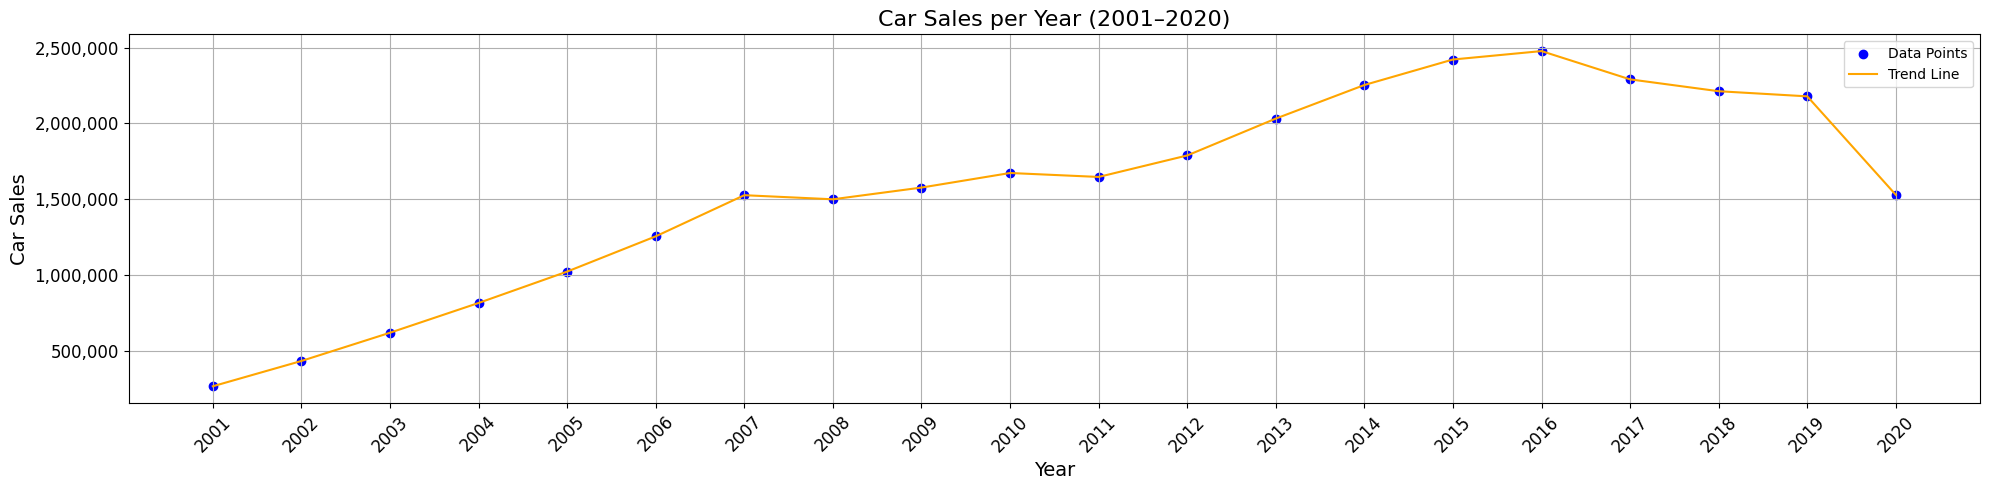

In [47]:
plt.figure(figsize=(20, 5))
plt.scatter(years, carSalesPerYear, color='blue', label='Data Points')
plt.plot(years, carSalesPerYear, color='orange', label='Trend Line')

plt.title("Car Sales per Year (2001–2020)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Car Sales", fontsize=14)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xticks(years, rotation=45)
plt.tick_params(axis='both', labelsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The number of car sales appears to have been on the rise over the years, with a slight decline in 2016.  However, 2019–2020 saw a sharp decline, which may be an anomaly because of outside influences like the COVID-19 pandemic and the numerous quarantines.

In [48]:
fuelPricesPerYear = fuelPricesDfClean.groupby('Year').mean()
fuelPricesPerYear

,Unnamed: 0,Pump price in pence/litre (ULSP),Pump price in pence/litre (ULSD),Duty rate in pence/litre (ULSP),Duty rate in pence/litre (ULSD),VAT percentage rate (ULSP),VAT percentage rate (ULSD)
Year,,,,,,,
2003,16.5,75.592000,77.288000,46.374667,46.374667,17.500000,17.500000
2004,57.5,80.254808,81.893462,47.100000,47.100000,17.500000,17.500000
2005,109.5,86.796923,90.820385,47.100000,47.100000,17.500000,17.500000
2006,161.5,91.395192,95.178462,47.172115,47.172115,17.500000,17.500000
2007,214.0,94.494717,97.112075,48.878302,48.878302,17.500000,17.500000
2008,266.5,107.001154,117.557115,50.542308,50.542308,17.259615,17.259615
2009,318.5,99.593846,104.150385,54.383846,54.383846,15.000000,15.000000
2010,370.5,116.903654,119.234423,57.190000,57.190000,17.500000,17.500000
2011,422.5,133.413269,138.805385,58.180769,58.180769,19.951923,19.951923


In [49]:
fuelPricesPerYear.mean(axis=1)

,0
Year,
2003,42.447048
2004,49.835467
2005,59.473901
2006,68.202555
2007,76.909057
2008,89.523159
2009,94.430275
2010,108.002582
2011,121.569148


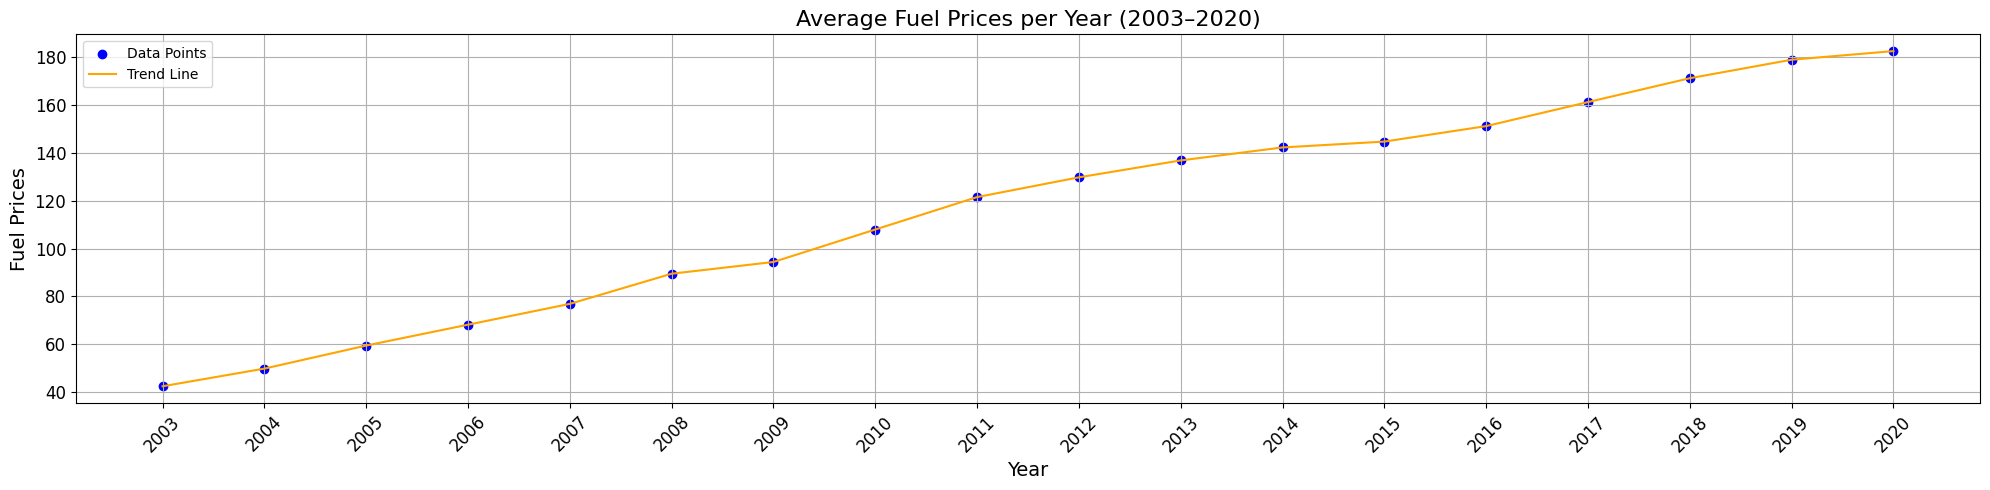

In [50]:
average_fuel_prices = fuelPricesPerYear.mean(axis=1)

plt.figure(figsize=(20, 5))
plt.scatter(years[2:], average_fuel_prices, color='blue', label='Data Points')
plt.plot(years[2:], average_fuel_prices, color='orange', label='Trend Line')

plt.title("Average Fuel Prices per Year (2003–2020)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Fuel Prices", fontsize=14)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xticks(years[2:], rotation=45)
plt.tick_params(axis='both', labelsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot indicates that fuel prices have been rising over time, albeit not linearly, with 2012 seeing the highest price.

 When comparing the graphs for car sales and fuel prices, it is evident that, with the exception of special cases like quarantines, car sales were unaffected by changes in fuel prices.  This suggests that even if fuel prices change, people won't be discouraged from buying cars.

### **5.2:** Reflection

If I had more time to complete this project, I would expand the analysis by exploring regional trends in car sales versus fuel prices, assuming geographic data could be acquired. I would also investigate more granular timeframes (e.g., monthly sales) to see if short-term fuel price changes impact consumer behavior. Additionally, I would look into vehicle types (e.g., electric vs. petrol) to explore how fuel prices influence shifts in car preferences over time.

In [ ]:
from google.colab import files
files.download('/content/final_report.html')

In [ ]:
!jupyter nbconvert --to html '/content/Data_Wrangling_Project_Starter.ipynb' --output '/content/final_report.html'
